# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

### Data

In [44]:
processor = DataProcessor()
data = processor.get_optimization_data()

In [54]:
w0 = get_initial_portfolio(data['mu'].shape[0])
mu = data['mu']
sigma = data['sigma']
lam = 0.5
c = 0.00001
w_prev = w0
model_non_smooth = NonSmoothMarkowitzModel({
    "mu": mu,
    "sigma": sigma,
    "lam": lam,
    "c": c,
    "w_prev":w_prev
})
model = SmoothMarkowitzModel({
    "mu": mu,
    "sigma": sigma,
    "lam": lam,
})
L = model.lipschitz_constant()


import cvxpy as cp


n = len(mu)
w = cp.Variable(n)

objective = (
    0.5 * cp.quad_form(w, sigma)
    - lam * mu @ w
    + c * cp.norm1(w - w_prev)
)

# ADD SIMPLEX CONSTRAINTS! This was missing before.
constraints = [cp.sum(w) == 1, w >= 0]

problem = cp.Problem(cp.Minimize(objective), constraints)
problem.solve(solver=cp.SCS)

w_opt = w.value
print(f"CVXPY optimal value: {model_non_smooth.f(w_opt)}")
f_ref = model_non_smooth.f(w_opt)
print(f"f_ref = {f_ref:.8f}")

CVXPY optimal value: -0.0010288383422165917
f_ref = -0.00102884


### Subgradient

In [46]:


# Estimate D and M for theoretical bounds
w0 = get_initial_portfolio(data['mu'].shape[0] ,method='random')
M = L + np.linalg.norm(mu) + c * np.sqrt(len(mu))
print(f"Estimated M (subgradient bound): {M:.4f}")

method = ProjectedSubgradientMethod({
    'step_size': 1e-6/M**2,
    'step_size_rule': 'constant',
    'max_iter': 10000,
    'tol': 1e-6,
}, ValuePerformanceIndicator_with_ref(f_ref=f_ref))
# result = method.optimize(model_non_smooth, w0.copy())
# print(result['converged'])
# print(result['value'])
# print(result['iterations'])

method = ProjectedSubgradientMethod({
    'step_size': 0.01,
    'step_size_rule': 'diminishing',
    'max_iter': 100000,
    'tol': 1e-6,
}, ValuePerformanceIndicator_with_ref(f_ref=f_ref))
# result = method.optimize(model_non_smooth, w0.copy())
# print(result['converged'])
# print(result['value'])
# print(result['iterations'])

# plot_convergence(result, save_dir=None)



Estimated M (subgradient bound): 0.0481


### Plot 2: Complexity vs Precision ε

For each precision $\varepsilon$, measure the number of iterations $T$ needed to reach $\varepsilon$-accuracy.
Compare with theoretical complexity $O(1/\varepsilon^2)$.

In [47]:
# Define range of epsilons to test
epsilons = np.logspace(-2, -8, 8)  # de 1e-2 à 1e-6


# Plot 2: Complexity vs Precision

# plot_subgradient_complexity(model_non_smooth, w0, f_ref, M, epsilons, max_iter=100000,
#                                  method_name='Subgradient', save_dir=None)

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 152
Final objective value: -0.0010278399691438873


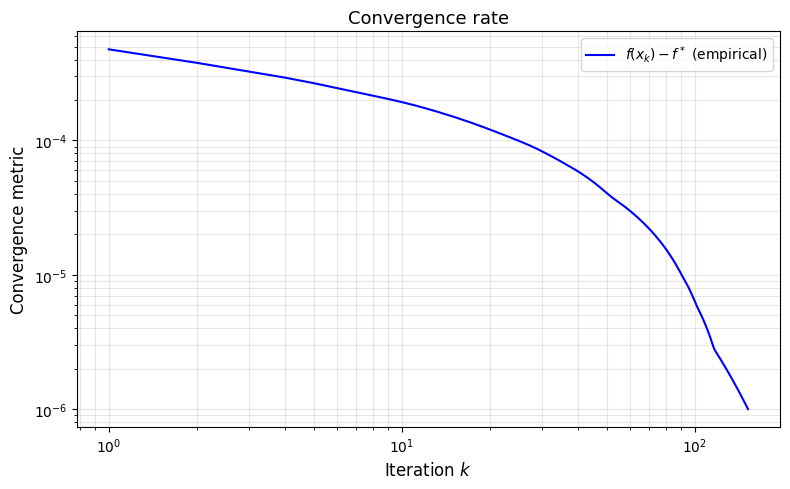

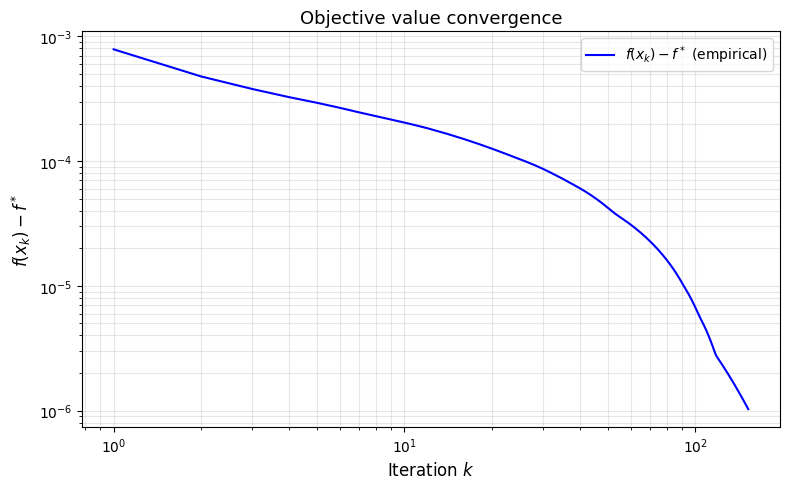

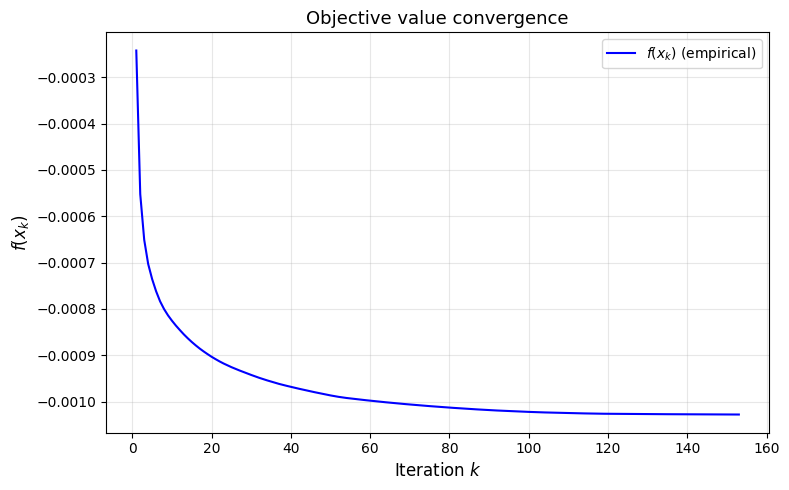

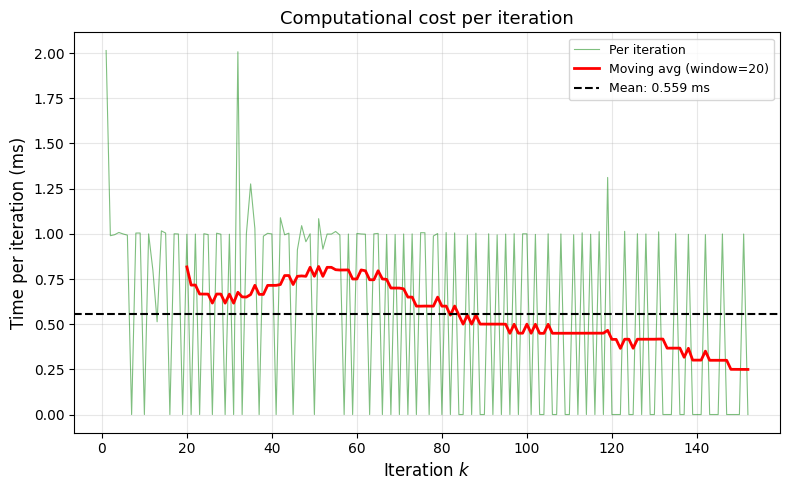

Total time: 0.0850 seconds
Total iterations: 152
Final objective value: -0.001028
Average time per iteration: 0.5590 ms
Std time per iteration: 0.5255 ms


In [55]:
# Proximal Gradient Method
# Use the SAME w0 as subgradient method for fair comparison

method_proximal = ProximalGradientMethod({
    'step_size': 1/L,           # Use 1/L for convergence guarantee
    'max_iter': 10000,
    'tol': 1e-6,
}, ValuePerformanceIndicator_with_ref(f_ref=f_ref))

# Use the SAME w0 as the subgradient method (don't redefine it!)
result_ProximalGradient = method_proximal.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProximalGradient.keys())
print(f"Converged: {result_ProximalGradient['converged']}")
print(f"Iterations: {result_ProximalGradient['iterations']}")
print(f"Final objective value: {result_ProximalGradient['value']}")


# Plot convergence
plot_convergence(result_ProximalGradient, method_name="Proximal_Gradient_Method", save_dir="../figures", metric_used='function_with_ref' , f_ref=f_ref)

  tol=1.00e-02: 1 iterations
  tol=2.15e-03: 1 iterations
  tol=4.64e-04: 2 iterations
  tol=1.00e-04: 25 iterations
  tol=2.15e-05: 71 iterations
  tol=4.64e-06: 107 iterations
  tol=1.00e-06: 152 iterations
  tol=2.15e-07: 208 iterations
  tol=4.64e-08: 285 iterations
  tol=1.00e-08: did not converge in 10000 iterations


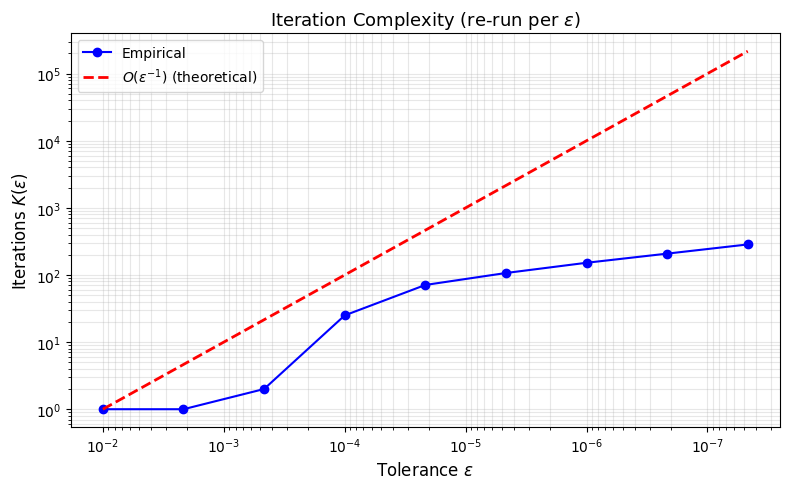

In [49]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-8

result_complexity = measure_iteration_complexity(
    method_class=ProximalGradientMethod,
    method_params={
        'step_size': 1/L,
        'max_iter': 10000,
        'tol': 1e-16,
    },
    model=model_non_smooth,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='ProximalGradientMethod',
    save_dir='../figures',
    metrics='function_with_ref',
    f_ref=f_ref 
)

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: False
Iterations: 10000
Final objective value: -0.001029


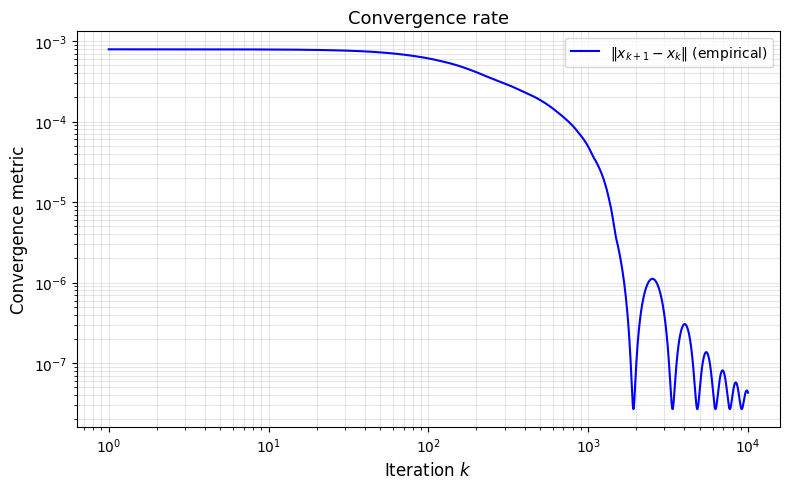

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

<Figure size 800x500 with 0 Axes>

In [50]:
# Constant step size only converges to a neighborhood of the optimum
method = ProximalGradientMethod_fast({
    'step_size': 0.01,              # Initial step size α_0
    'max_iter': 10000,
    'tol': 1e-8,
}, ValuePerformanceIndicator_with_ref(f_ref))

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0] , method="random")

# Optimize portfolio on training data
result_ProjectedSubgradientMethod = method.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProjectedSubgradientMethod.keys())
print(f"Converged: {result_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result_ProjectedSubgradientMethod['value']:.6f}")

# Plot convergence
plot_convergence(result_ProjectedSubgradientMethod)

  tol=1.00e-02: 1 iterations
  tol=3.46e-03: 1 iterations
  tol=1.19e-03: 1 iterations
  tol=4.12e-04: 1 iterations
  tol=1.43e-04: 1 iterations
  tol=4.92e-05: 1 iterations
  tol=1.70e-05: 1 iterations
  tol=5.88e-06: 1 iterations
  tol=2.03e-06: 1 iterations
  tol=7.02e-07: 1 iterations
  tol=2.42e-07: 1 iterations
  tol=8.38e-08: 1 iterations
  tol=2.89e-08: 1 iterations
  tol=1.00e-08: 1 iterations


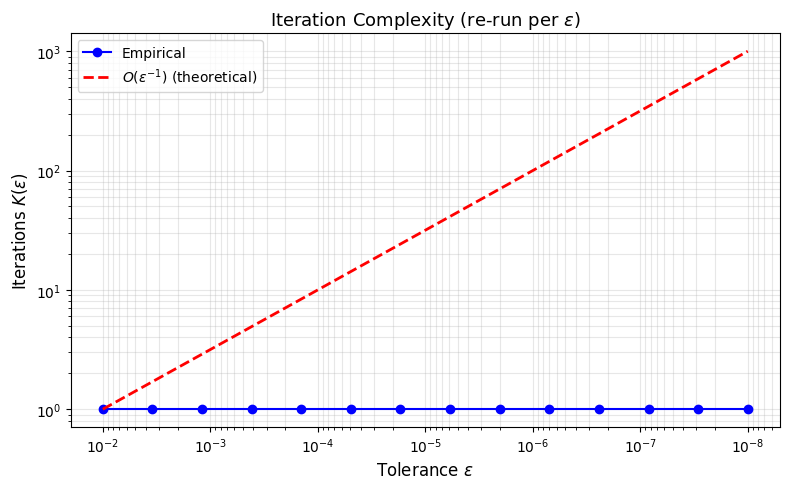

In [ ]:
tolerances = np.logspace(-2, -8, 14)  # de 1e-2 à 1e-8

result_complexity = measure_iteration_complexity(
    method_class=ProximalGradientMethod_fast,
    method_params={
        'step_size': 1/L,
        'max_iter': 10000,
    },
    model=model_non_smooth,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=0.5,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='ProximalGradientMethod_fast',
    save_dir='../figures',
    metrics='function_with_ref',
    f_ref=f_ref 
)